# Chuar Group ca. 755 Ma paleomagnetic pole
## Geologic context
The Chuar Group of the Grand Canyon (Arizona) is a ~1.6-km-thick succession of
Neoproterozoic (Tonian) mudstone, dolomite, and sandstone deposited in an
extensional basin during the early breakup of Rodinia (Weil, Geissman & Van der
Voo, 2004; Eyster et al., 2020). It is divided into the lower Galeros and upper
Kwagunt formations. This notebook builds a combined pole spanning three members:
the Carbon Canyon member of the Galeros Formation and the Carbon Butte and Awatubi
members of the Kwagunt Formation, using the age model of Dehler et al. (2023).

## Age constraints from the Dehler et al. (2023) Bayesian age model
Dehler et al. (2023) constructed a continuous Bayesian (modifiedBchron) age-height
model for the Chuar Group, anchored on the youngest detrital zircon maximum
depositional age in the basal Nankoweap Formation (770.1 ± 0.5 Ma), two Re-Os
dates from the Galeros and Kwagunt formations, and a U-Pb zircon tuff date of
729.0 ± 0.9 Ma in the uppermost Walcott Member (Rooney et al., 2018). The model
yields the following median ages and 95% credible intervals for the bases of the
three paleomagnetically sampled members:
- Carbon Canyon member (Galeros Fm), base at 561 m: 760.68 Ma (755.45–765.97 Ma).
  Anchored nearby by a Re-Os whole-rock date on Carbon Canyon Member carbonate
  (757.0 ± 6.8 Ma; modeled to 757.30 Ma, 752.17–762.42 Ma; Rooney et al., 2018).
- Carbon Butte member (Kwagunt Fm), base at 1180 m: 749.74 Ma (743.90–754.87 Ma).
- Awatubi member (Kwagunt Fm), base at 1227 m: 748.35 Ma (742.14–753.47 Ma).
  Constrained by a Re-Os date on Awatubi Member marcasite nodules (751.0 ± 7.6 Ma;
  modeled to 748.13 Ma, 741.89–753.24 Ma; Rooney et al., 2018). The paleomagnetic 
  data of Eyster et al., (2020) from the Awatubi come from its very base just above the Carbon Butte member.

## Pole
The combined Chuar Group pole is the equal-weight Fisher mean of 37 individual
tilt-corrected site/sample virtual geomagnetic poles (VGPs), reproducing Eyster
et al. (2020) Table 1: Carbon Butte–Awatubi (N = 23) + Carbon Canyon (N = 14).
The 17 Eyster (2020) high-temperature (HT) Carbon Butte–Awatubi readings are
reconstructed from their Supplemental Table S2 (see below); the remaining 20 are
Weil et al. (2004) site VGPs (6 Carbon Butte + 14 Carbon Canyon). The HT remanence
is carried by hematite, is of dual polarity, and passes a fold test, indicating a
primary, pre-folding origin. Because the combined pole averages ~10 Myr of
apparent polar wander between the older Carbon Canyon member and the younger
Kwagunt members, it sits at a lower paleolatitude than the Kwagunt-only pole.

## References
- Dehler, C., Schmitz, M., Bullard, A., Porter, S., Timmons, M., Karlstrom, K., & Cothren, H. (2023). Precise U-Pb age models refine Neoproterozoic western Laurentian rift initiation, correlation, and Earth system changes. *Precambrian Research*, 396, 107156. https://doi.org/10.1016/j.precamres.2023.107156
- Eyster, A., Weiss, B. P., Karlstrom, K., & Macdonald, F. A. (2020). Paleomagnetism of the Chuar Group and evaluation of the late Tonian Laurentian apparent polar wander path with implications for the makeup and breakup of Rodinia. *GSA Bulletin*, 132(3–4), 710–738. https://doi.org/10.1130/B32012.1
- Rooney, A. D., Austermann, J., Smith, E. F., Li, Y., Selby, D., Dehler, C. M., Schmitz, M. D., Karlstrom, K. E., & Macdonald, F. A. (2018). Coupled Re-Os and U-Pb geochronology of the Tonian Chuar Group, Grand Canyon. *GSA Bulletin*, 130(7–8), 1085–1098. https://doi.org/10.1130/B31768.1
- Weil, A. B., Geissman, J. W., & Van der Voo, R. (2004). Paleomagnetism of the Neoproterozoic Chuar Group, Grand Canyon Supergroup, Arizona: implications for Laurentia's Neoproterozoic APWP and Rodinia break-up. *Precambrian Research*, 129(1–2), 71–92. https://doi.org/10.1016/j.precamres.2003.09.016

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Reconstructing Eyster (2020) HT samples from Supplemental Table S2

Eyster et al. (2020) report their Carbon Butte–Awatubi pole at the sample level
("treating every sample as a site"), but the published MagIC contribution carries
only the locality means. The 17 sample-level HT readings are reconstructed here
from their Supplemental Table S2 (GSA Data Repository 2019239), parsed into
`Eyster2020_SI_DR2.txt`. The selection rule that reproduces their N = 17 pole
(12.5°N/161.6°E, A95 4.0°) is: **linear (best-fit-line) shallow-HT components with
MAD < 15°, one direction per sample** (samples with two distinct unblocking
directions are averaged). Great-circle (arc) fits are used by Eyster only in the
locality means, not in the every-sample pole, and are excluded. The six localities
map to members: A1303/A1305/A1306/A1310 = Carbon Butte, A1304/A1307 = Awatubi.

This reconstruction is baked into the contribution `sites.txt`; the cell below
loads the result.

In [2]:
sites = pd.read_csv('../data/755_Chuar/sites.txt', sep='\t', skiprows=1)
tc = sites[sites['dir_tilt_correction'] == 100].copy()
geo = sites[sites['dir_tilt_correction'] == 0].copy()
study_lat, study_lon = 36.23, 248.13
print(tc.groupby(['member', 'study']).size())
print(f'\ntotal sites in the combined mean: {len(tc)}')

member         study               
Awatubi        Eyster et al. (2020)     4
Carbon Butte   Eyster et al. (2020)    13
               Weil et al. (2004)       6
Carbon Canyon  Weil et al. (2004)      14
dtype: int64

total sites in the combined mean: 37


## Component poles — reproducing Eyster (2020) Table 1

The Carbon Butte–Awatubi pole (17 Eyster samples + 6 Weil sites, N = 23) and the
Carbon Canyon pole (14 Weil sites) are computed from the site VGPs and compared
with Eyster's published values. The near-equatorial Carbon Canyon mean is flipped
to the compilation hemisphere (longitude ~164°E).

In [3]:
cb_awatubi = tc[tc['member'].isin(['Carbon Butte', 'Awatubi'])]
_, cba_pole = pt.compute_mean_pole(cb_awatubi, unify_polarity=True)
print(f"Carbon Butte-Awatubi (N={int(cba_pole['n'])}): "
      f"{cba_pole['inc']:.1f}N / {cba_pole['dec']:.1f}E   A95 {cba_pole['alpha95']:.1f}   "
      f"(Eyster 2020: 13.5N / 162.8E, A95 3.3, N=23)")

carbon_canyon = tc[tc['member'] == 'Carbon Canyon']
_, cc_pole = pt.compute_mean_pole(carbon_canyon, unify_polarity=True, flip=True)
print(f"Carbon Canyon        (N={int(cc_pole['n'])}): "
      f"{cc_pole['inc']:.1f}N / {cc_pole['dec']:.1f}E   A95 {cc_pole['alpha95']:.1f}   "
      f"(Eyster 2020: -2.1N / 163.7E, A95 8.0, N=14)")

Carbon Butte-Awatubi (N=23): 13.2N / 163.5E   A95 3.6   (Eyster 2020: 13.5N / 162.8E, A95 3.3, N=23)
Carbon Canyon        (N=14): -2.1N / 163.7E   A95 8.0   (Eyster 2020: -2.1N / 163.7E, A95 8.0, N=14)


## Member ChRM directions (tilt-corrected, mixed polarity)

Directions are plotted without unifying polarity (downward = filled, upward =
open); both polarities are present.

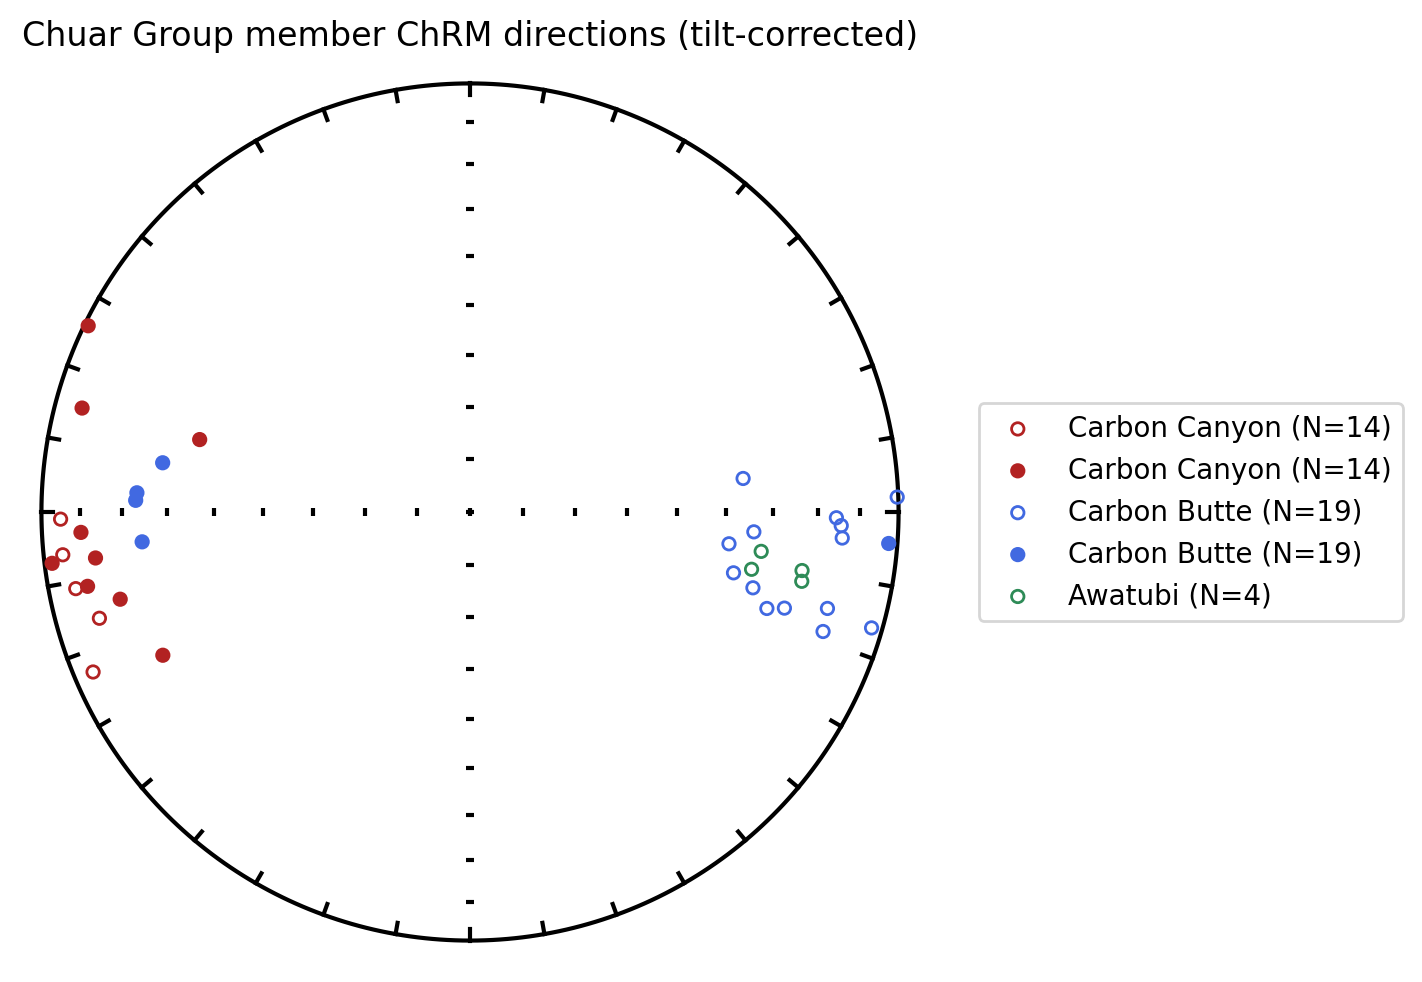

In [4]:
colors = {'Carbon Canyon': 'firebrick', 'Carbon Butte': 'royalblue', 'Awatubi': 'seagreen'}
ipmag.plot_net()
for m in ['Carbon Canyon', 'Carbon Butte', 'Awatubi']:
    sub = tc[tc['member'] == m]
    ipmag.plot_di(sub['dir_dec'].tolist(), sub['dir_inc'].tolist(),
                  color=colors[m], marker='o', label=f'{m} (N={len(sub)})')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.title('Chuar Group member ChRM directions (tilt-corrected)')
plt.show()

## The combined Chuar Group pole (N = 37)

The 37 tilt-corrected site/sample VGPs are pooled into a single equal-weight
Fisher mean — the exported value.

Combined Chuar Group pole: 7.5N / 163.6E   A95 4.2   K 32.1   N 37


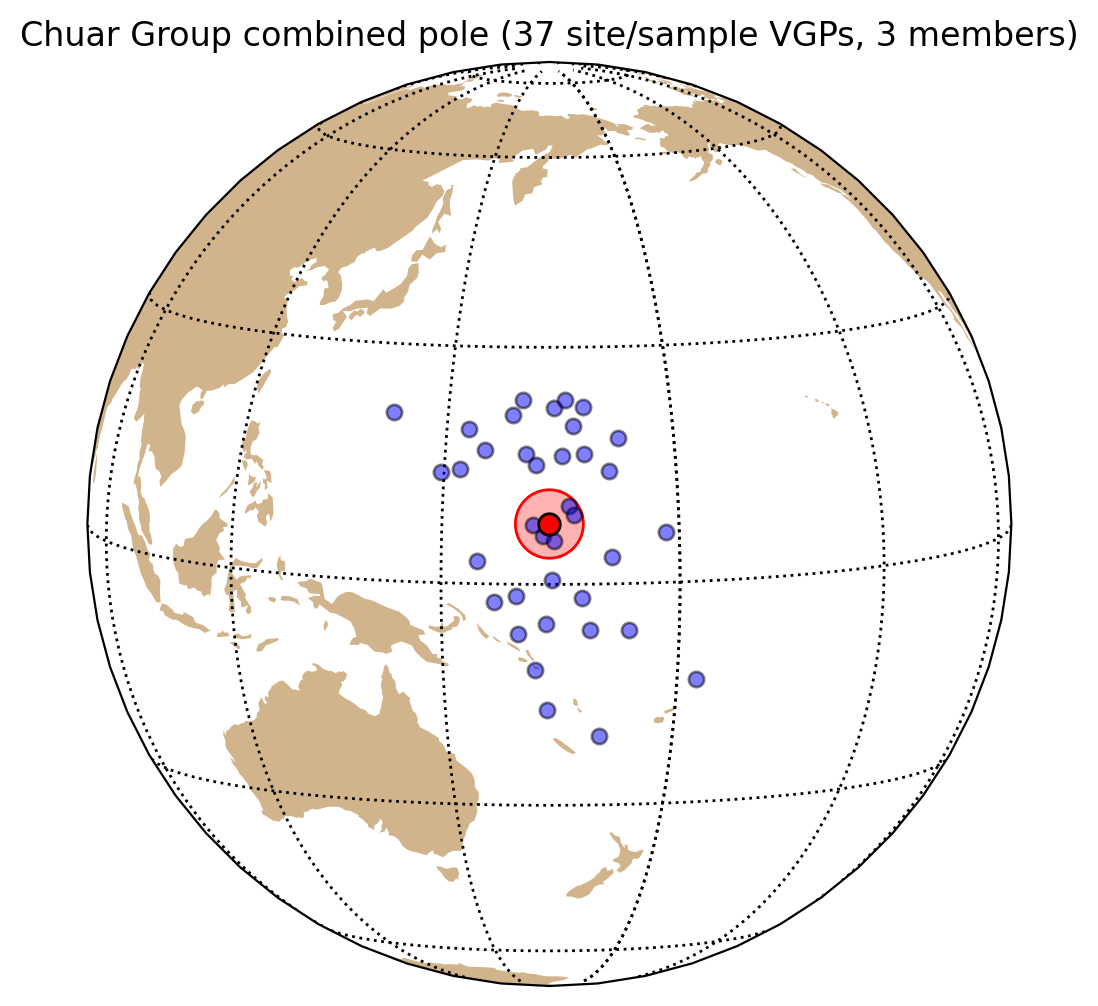

In [5]:
vgp_block, chuar_pole = pt.compute_mean_pole(tc, unify_polarity=True)
print(f"Combined Chuar Group pole: {chuar_pole['inc']:.1f}N / {chuar_pole['dec']:.1f}E   "
      f"A95 {chuar_pole['alpha95']:.1f}   K {chuar_pole['k']:.1f}   N {int(chuar_pole['n'])}")

ax = pt.plot_vgps_and_pole(vgp_block, chuar_pole, central_longitude=chuar_pole['dec'],
                           central_latitude=chuar_pole['inc'], figsize=(6, 6))
plt.title('Chuar Group combined pole (37 site/sample VGPs, 3 members)')
plt.show()

## Reversal test

The McFadden & McElhinny (1990) and bootstrap reversal tests are run on all 37
combined tilt-corrected directions. Polarity here is largely confounded with
member age — the Carbon Canyon member is dominantly of one polarity and the
younger Carbon Butte–Awatubi members the other — so the two polarity groups
differ by the ~10 Myr of apparent polar wander between the members, and the test
on the full combined set is negative. Within the coeval Carbon Butte–Awatubi
members the reversal test is positive (Watson V = 7.4 < V_crit = 7.6; MM1990
class C; Eyster et al., 2020). Both polarities are present (Meert R6).

37 directions (polarity 1: 18, polarity 2: 19)

McFadden & McElhinny (1990) reversal test
------------------------------------------


Results of Watson V test: 

Watson's V:           17.0
Critical value of V:  6.2
"Fail": Since V is greater than Vcrit, the two means can
be distinguished at the 95% confidence level.

M&M1990 classification:

Angle between data set means: 16.5
Critical angle for M&M1990:   10.0


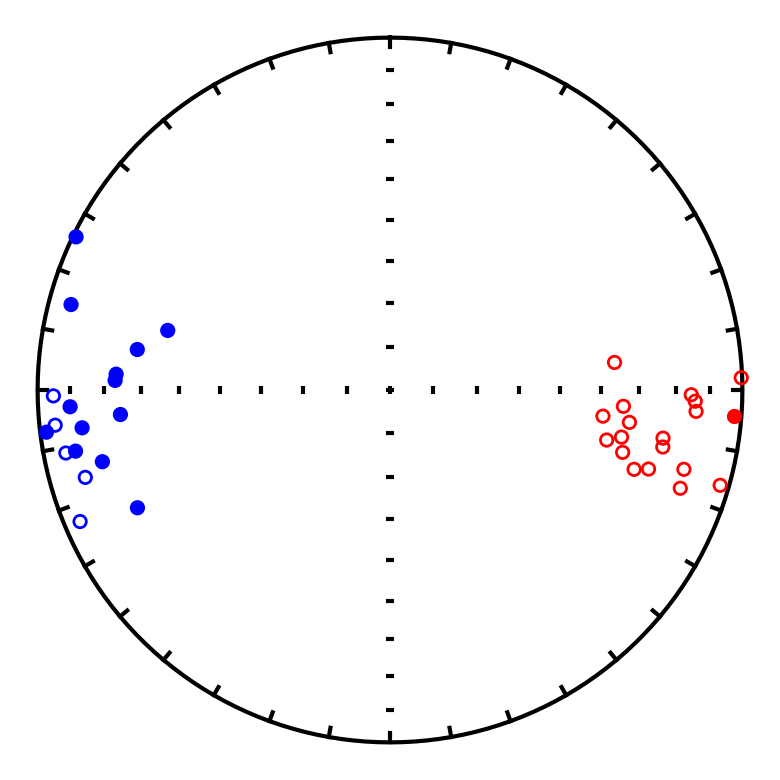


Bootstrap reversal test
------------------------------------------


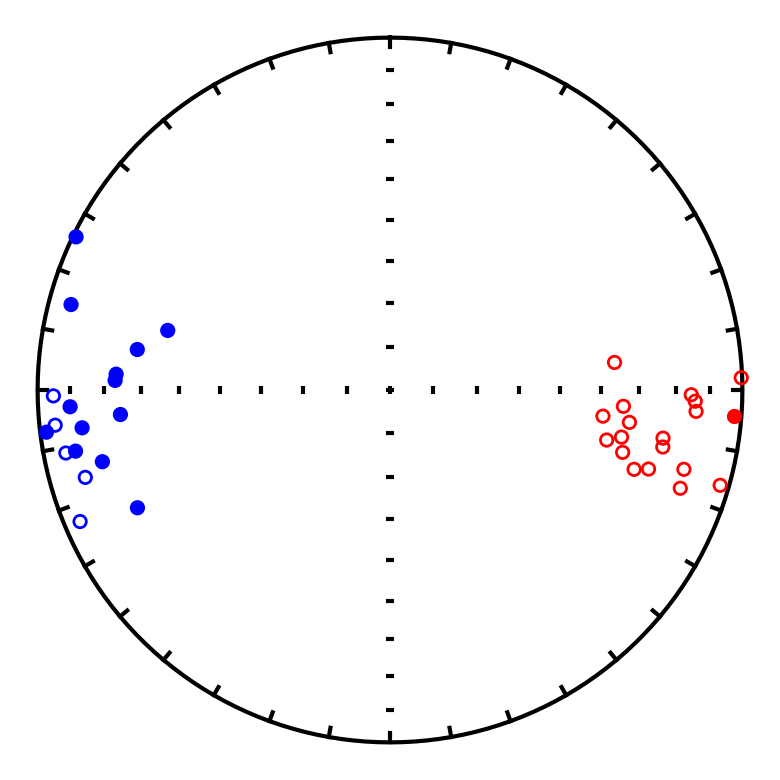

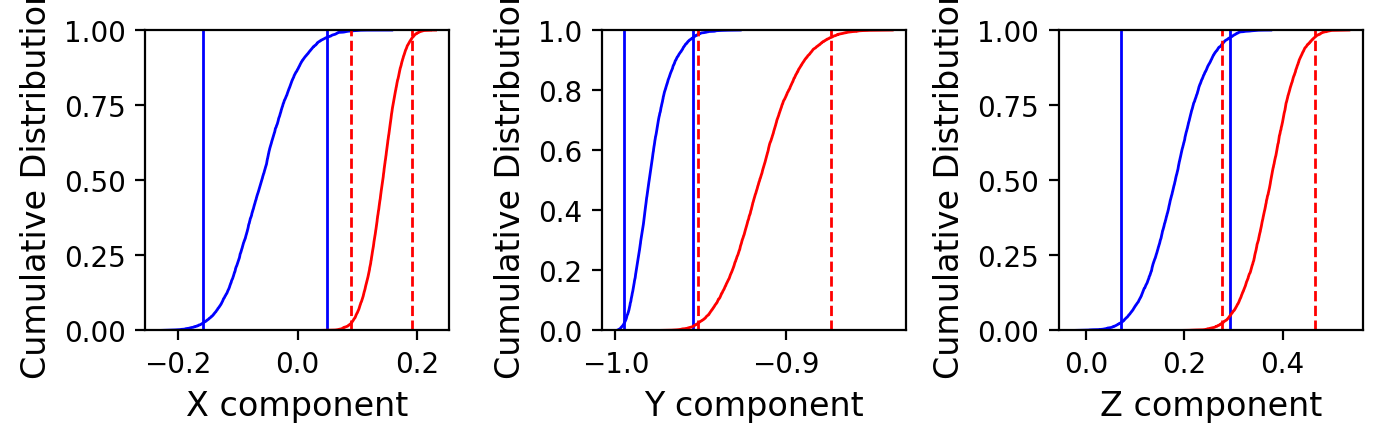

Fail, distinct in x and y


In [6]:
_ = pt.reversal_test(tc, plot=True, random_seed=1)

### Reversal test: coeval Carbon Butte–Awatubi members only

Restricting the test to the coeval Carbon Butte and Awatubi (Kwagunt) members
removes the inter-member apparent polar wander that confounds the full-set test.
On this dual-polarity subset the McFadden & McElhinny (1990) common-mean test is
positive (the normal and reversed modes share a mean direction), consistent with
the positive reversal test reported by Eyster et al. (2020).

23 directions (polarity 1: 4, polarity 2: 19)

McFadden & McElhinny (1990) reversal test
------------------------------------------


Results of Watson V test: 

Watson's V:           4.5
Critical value of V:  6.6
"Pass": Since V is less than Vcrit, the null hypothesis
that the two populations are drawn from distributions
that share a common mean direction can not be rejected.

M&M1990 classification:

Angle between data set means: 6.6
Critical angle for M&M1990:   8.1
The McFadden and McElhinny (1990) classification for
this test is: 'B'


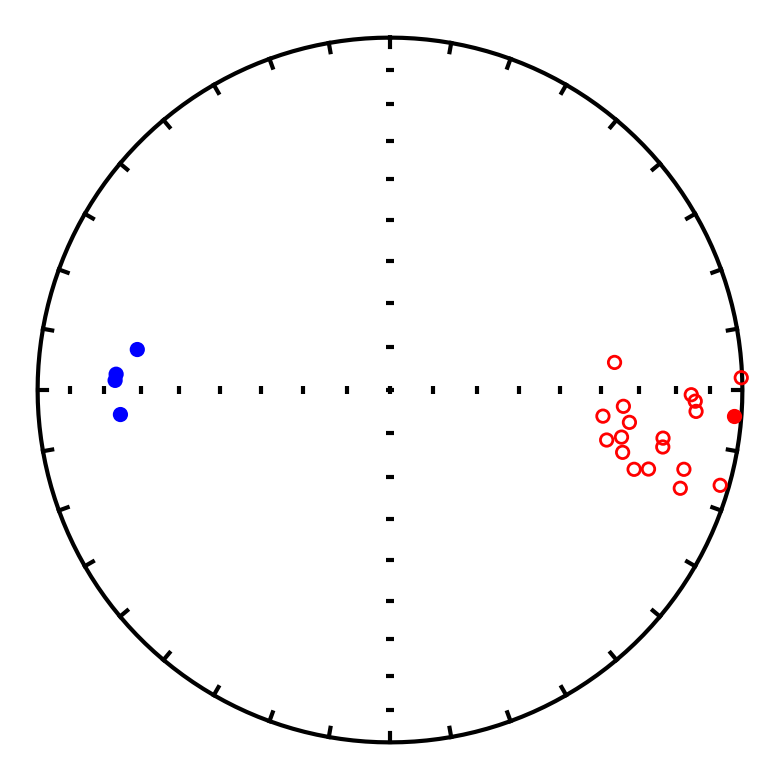


Bootstrap reversal test
------------------------------------------


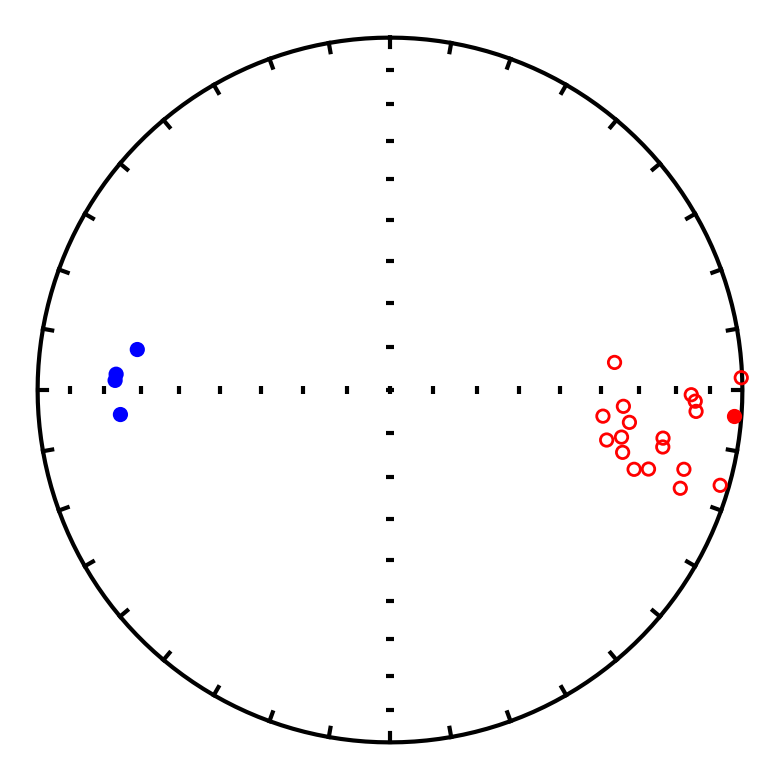

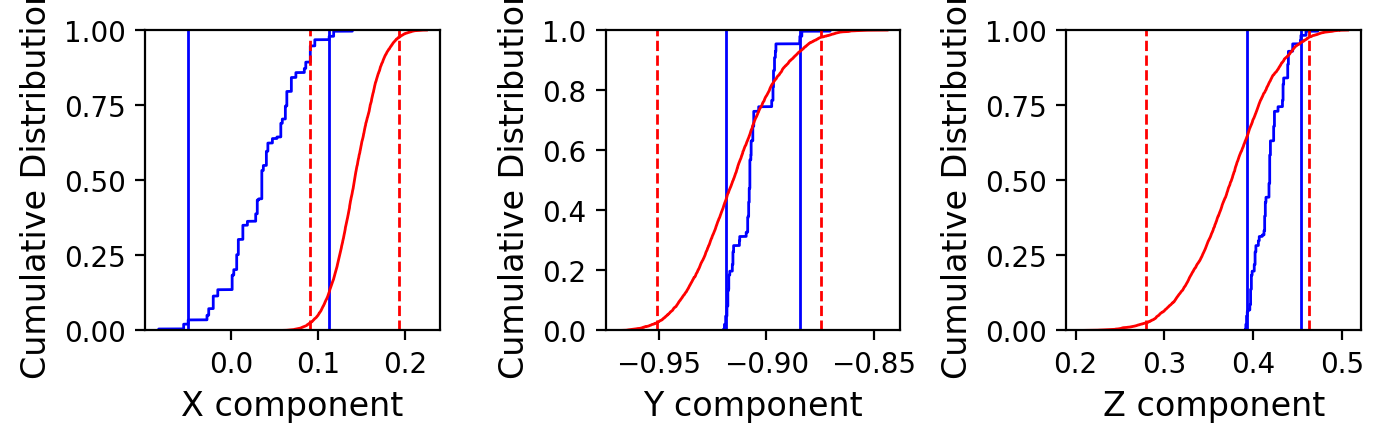

Pass


In [7]:
kwagunt = tc[tc['member'].isin(['Carbon Butte', 'Awatubi'])]
_ = pt.reversal_test(kwagunt, plot=True, random_seed=1)

## Fold test

The Tauxe & Watson (1994) fold test of Eyster et al. (2020) places the optimal
unfolding at 66-109%, indicating a pre-folding (primary) magnetization. As a
simple check, the precision parameter k of the polarity-unified ChRM should
increase from in-situ to tilt-corrected coordinates.

In [8]:
_, geo_mean = pt.compute_mean_direction(geo, unify_polarity=True)
_, tc_mean = pt.compute_mean_direction(tc, unify_polarity=True)
print(f"in-situ        : k = {geo_mean['k']:.1f}  (a95 = {geo_mean['alpha95']:.1f}, N = {int(geo_mean['n'])})")
print(f"tilt-corrected : k = {tc_mean['k']:.1f}  (a95 = {tc_mean['alpha95']:.1f}, N = {int(tc_mean['n'])})")
print('k increases on untilting -> positive fold test (cf. Tauxe & Watson 1994, 66-109% unfolding; Eyster et al., 2020)')

in-situ        : k = 8.8  (a95 = 8.4, N = 37)
tilt-corrected : k = 19.4  (a95 = 5.5, N = 37)
k increases on untilting -> positive fold test (cf. Tauxe & Watson 1994, 66-109% unfolding; Eyster et al., 2020)


## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation
at the sampling paleolatitude.

{'Mode': 'Mode 1',
 'Dec': np.float64(163.5426178704929),
 'Inc': np.float64(7.651325566767086),
 'N': 37,
 'Mu': np.float64(1.0017896450555648),
 'Mu_critical': 1.207,
 'Me': np.float64(0.8362141624235742),
 'Me_critical': 1.094,
 'Test_result': 'Consistent with Fisher distribution'}

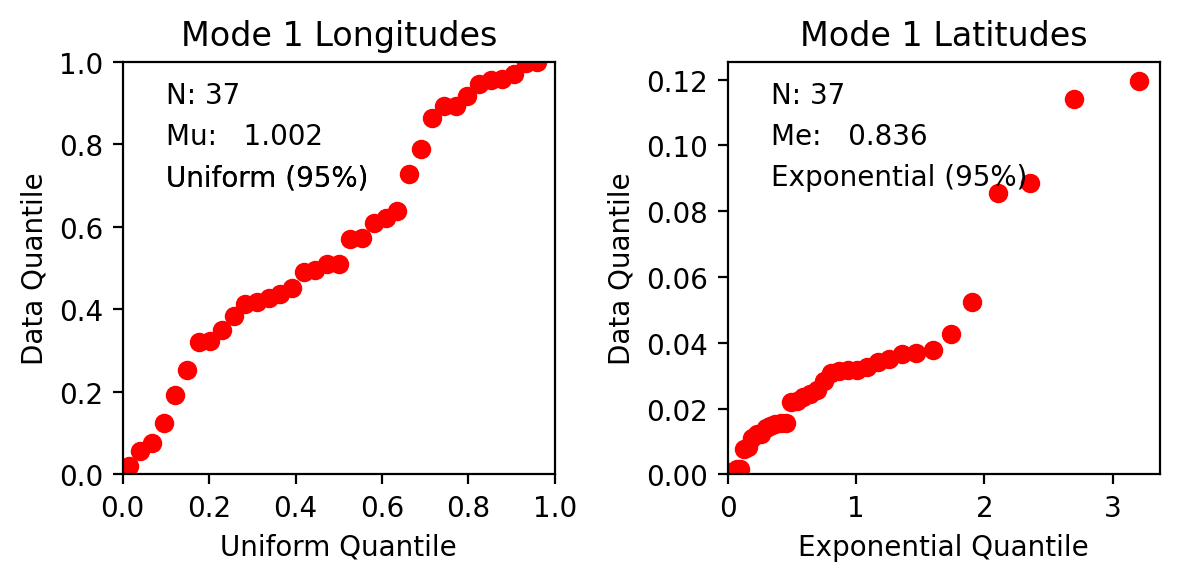

In [9]:
fishqq_result = pt.fishqq_vgps(tc, unify_polarity=True)
fishqq_result

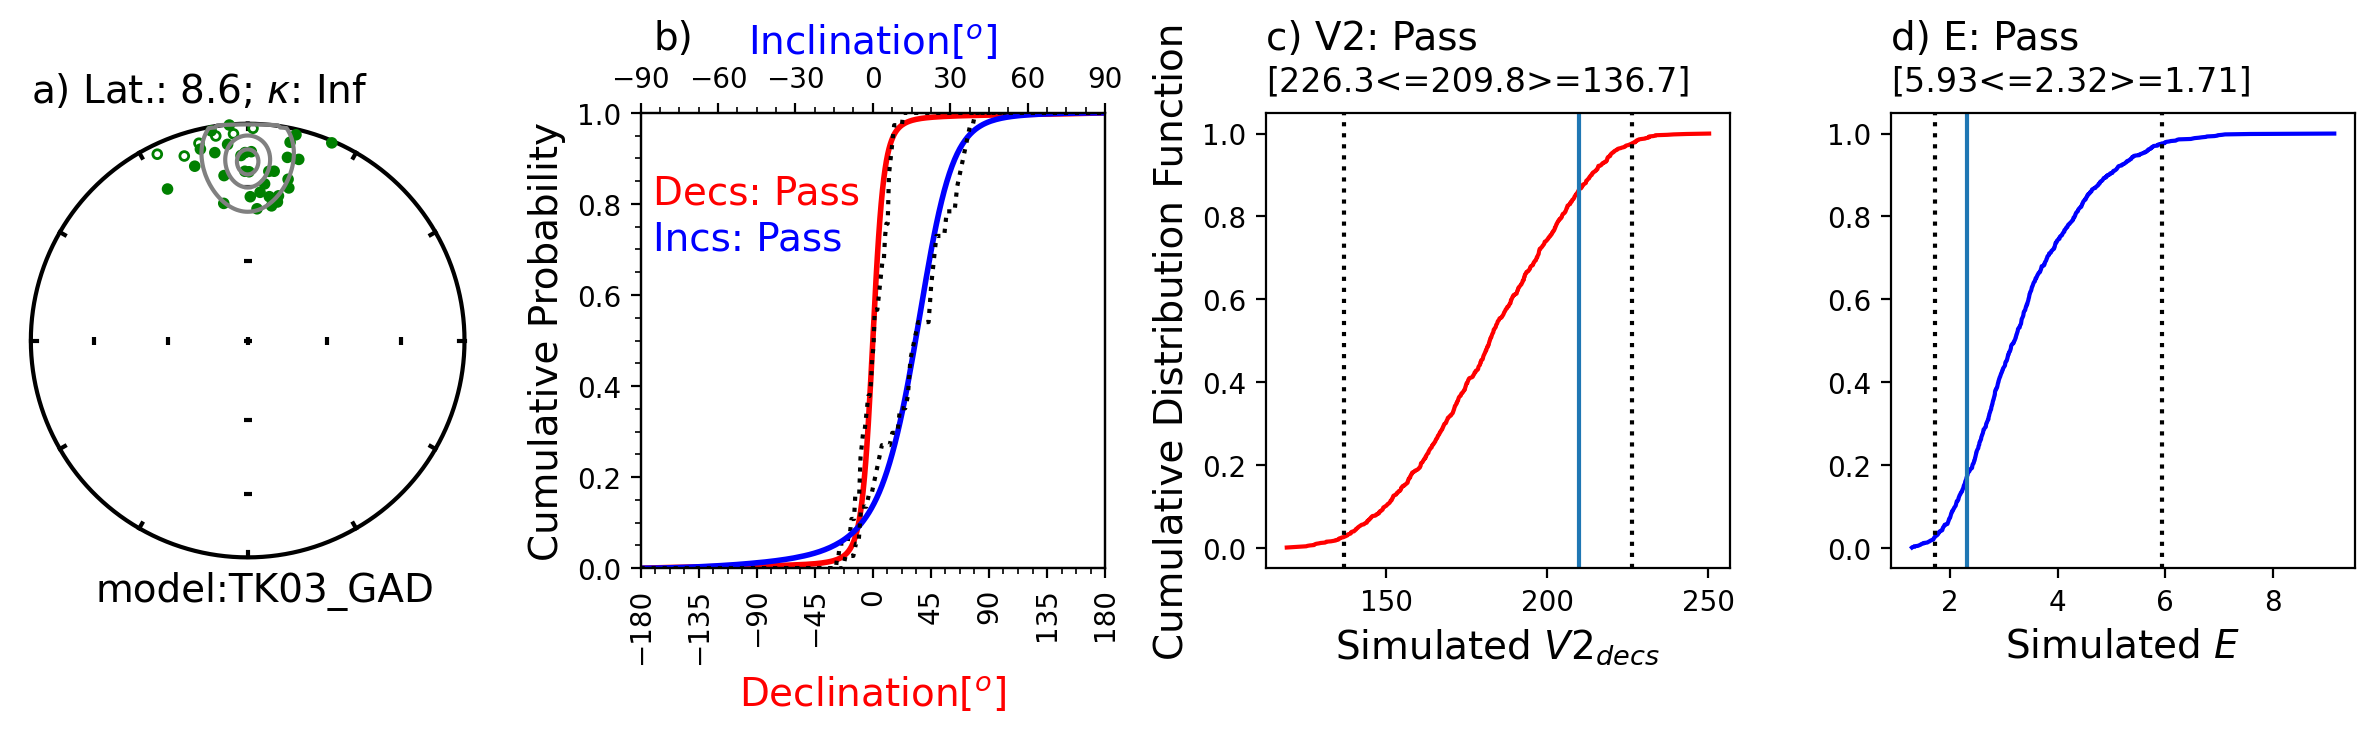

paleolatitude = 8.6 deg; elongation E = 2.32 (consistent with TK03.GAD)


In [10]:
_slat, _slon = float(tc['lat'].mean()), float(tc['lon'].mean())
try:
    svei_result = pt.svei_test_vgps(tc, _slon, _slat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(tc, _slon, _slat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The Chuar Group pole in the context of the Laurentia APWP

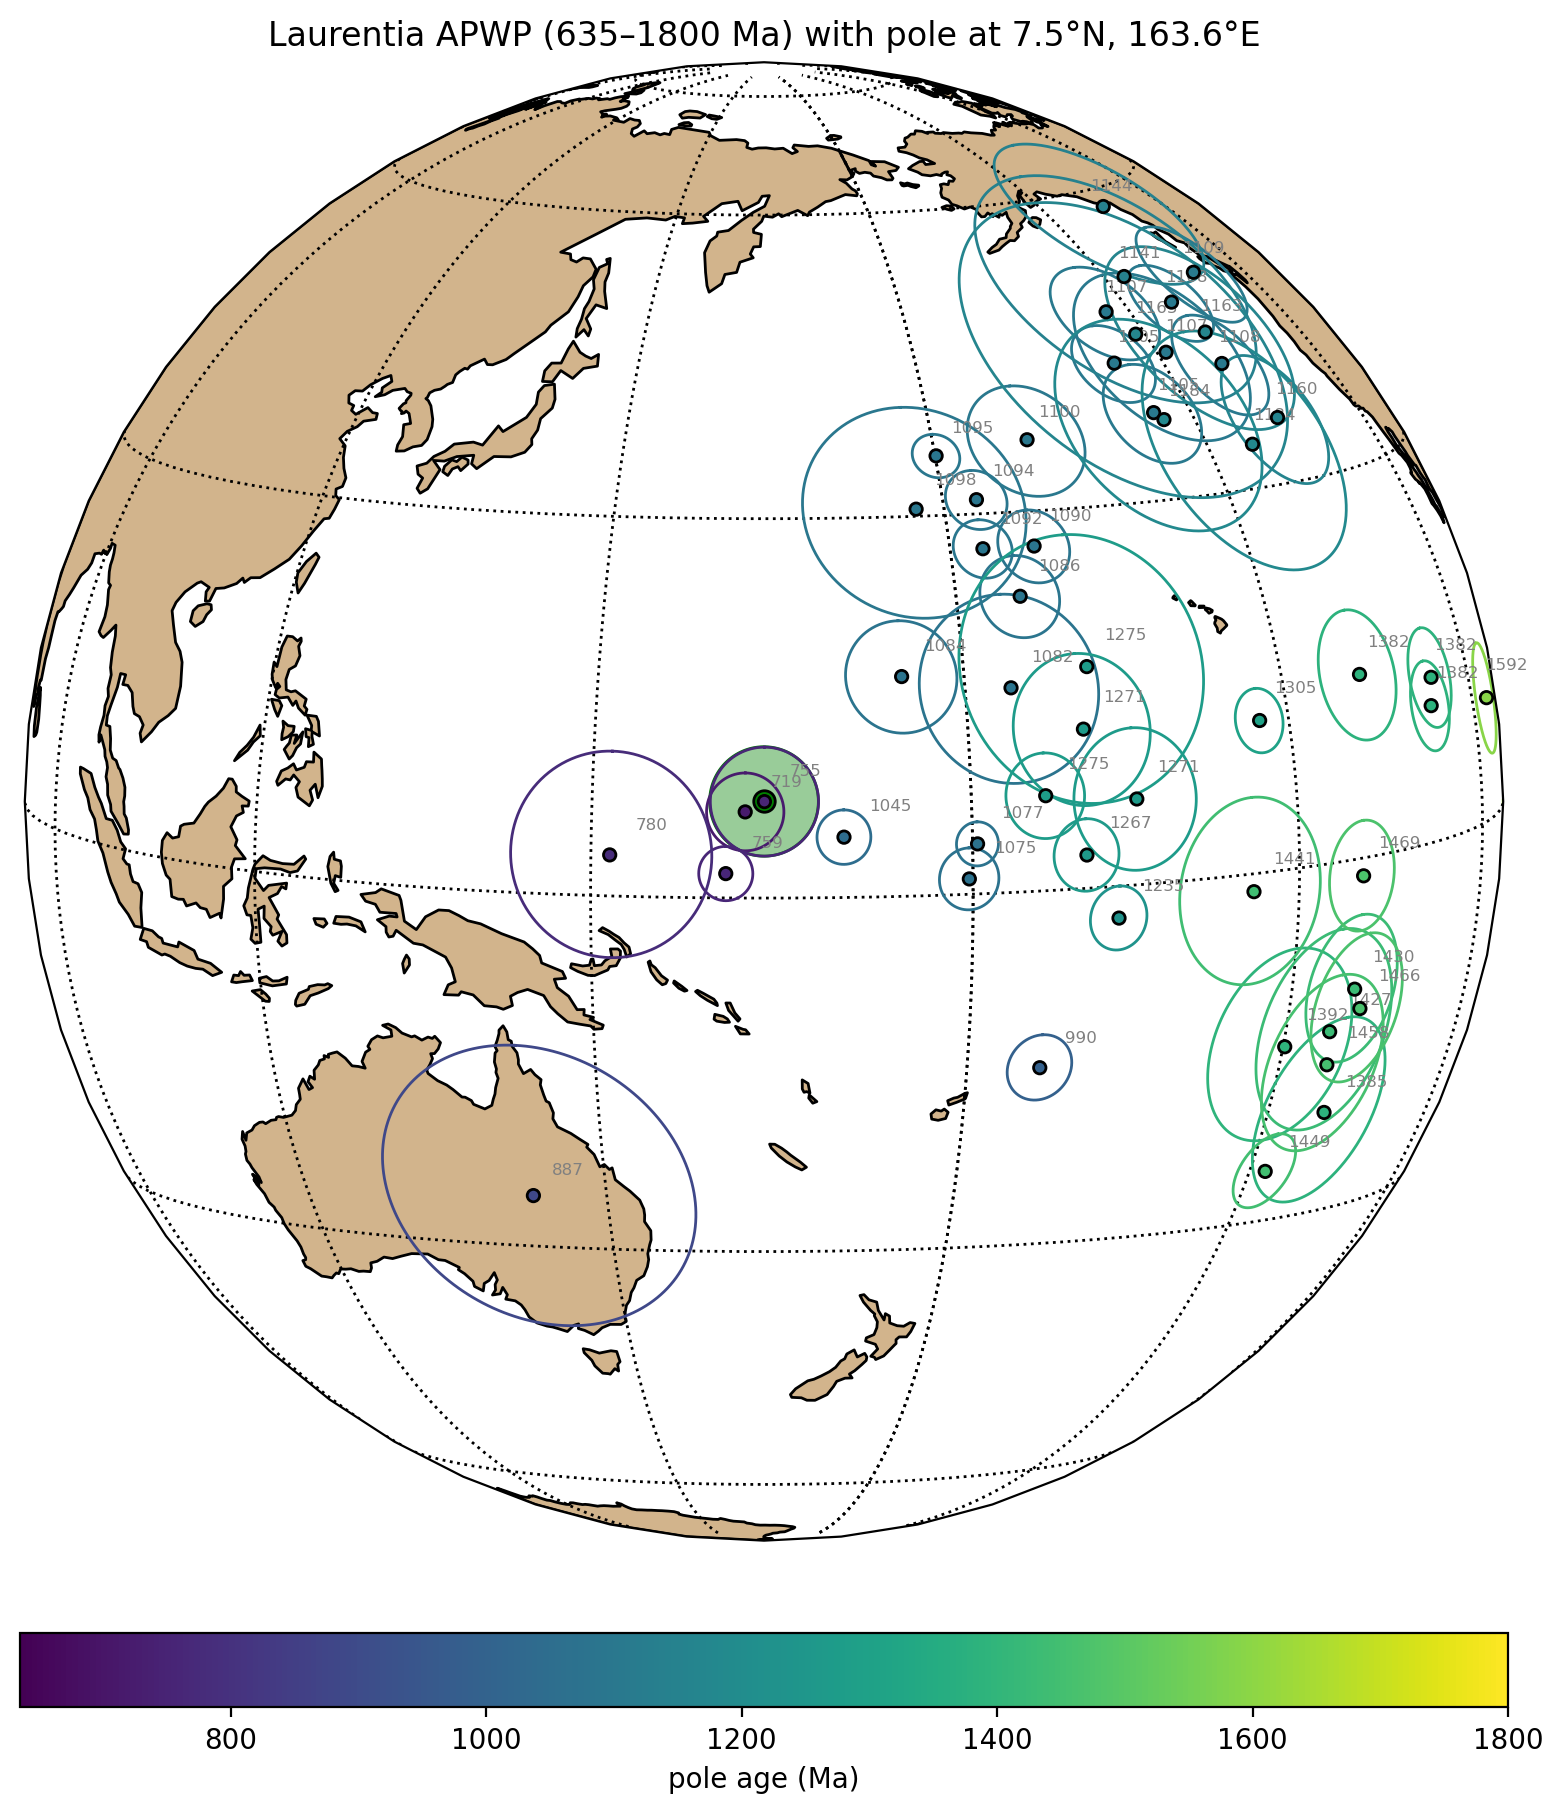

In [11]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, chuar_pole['inc'], chuar_pole['dec'],
                          chuar_pole['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=chuar_pole['dec'],
                          central_latitude=chuar_pole['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

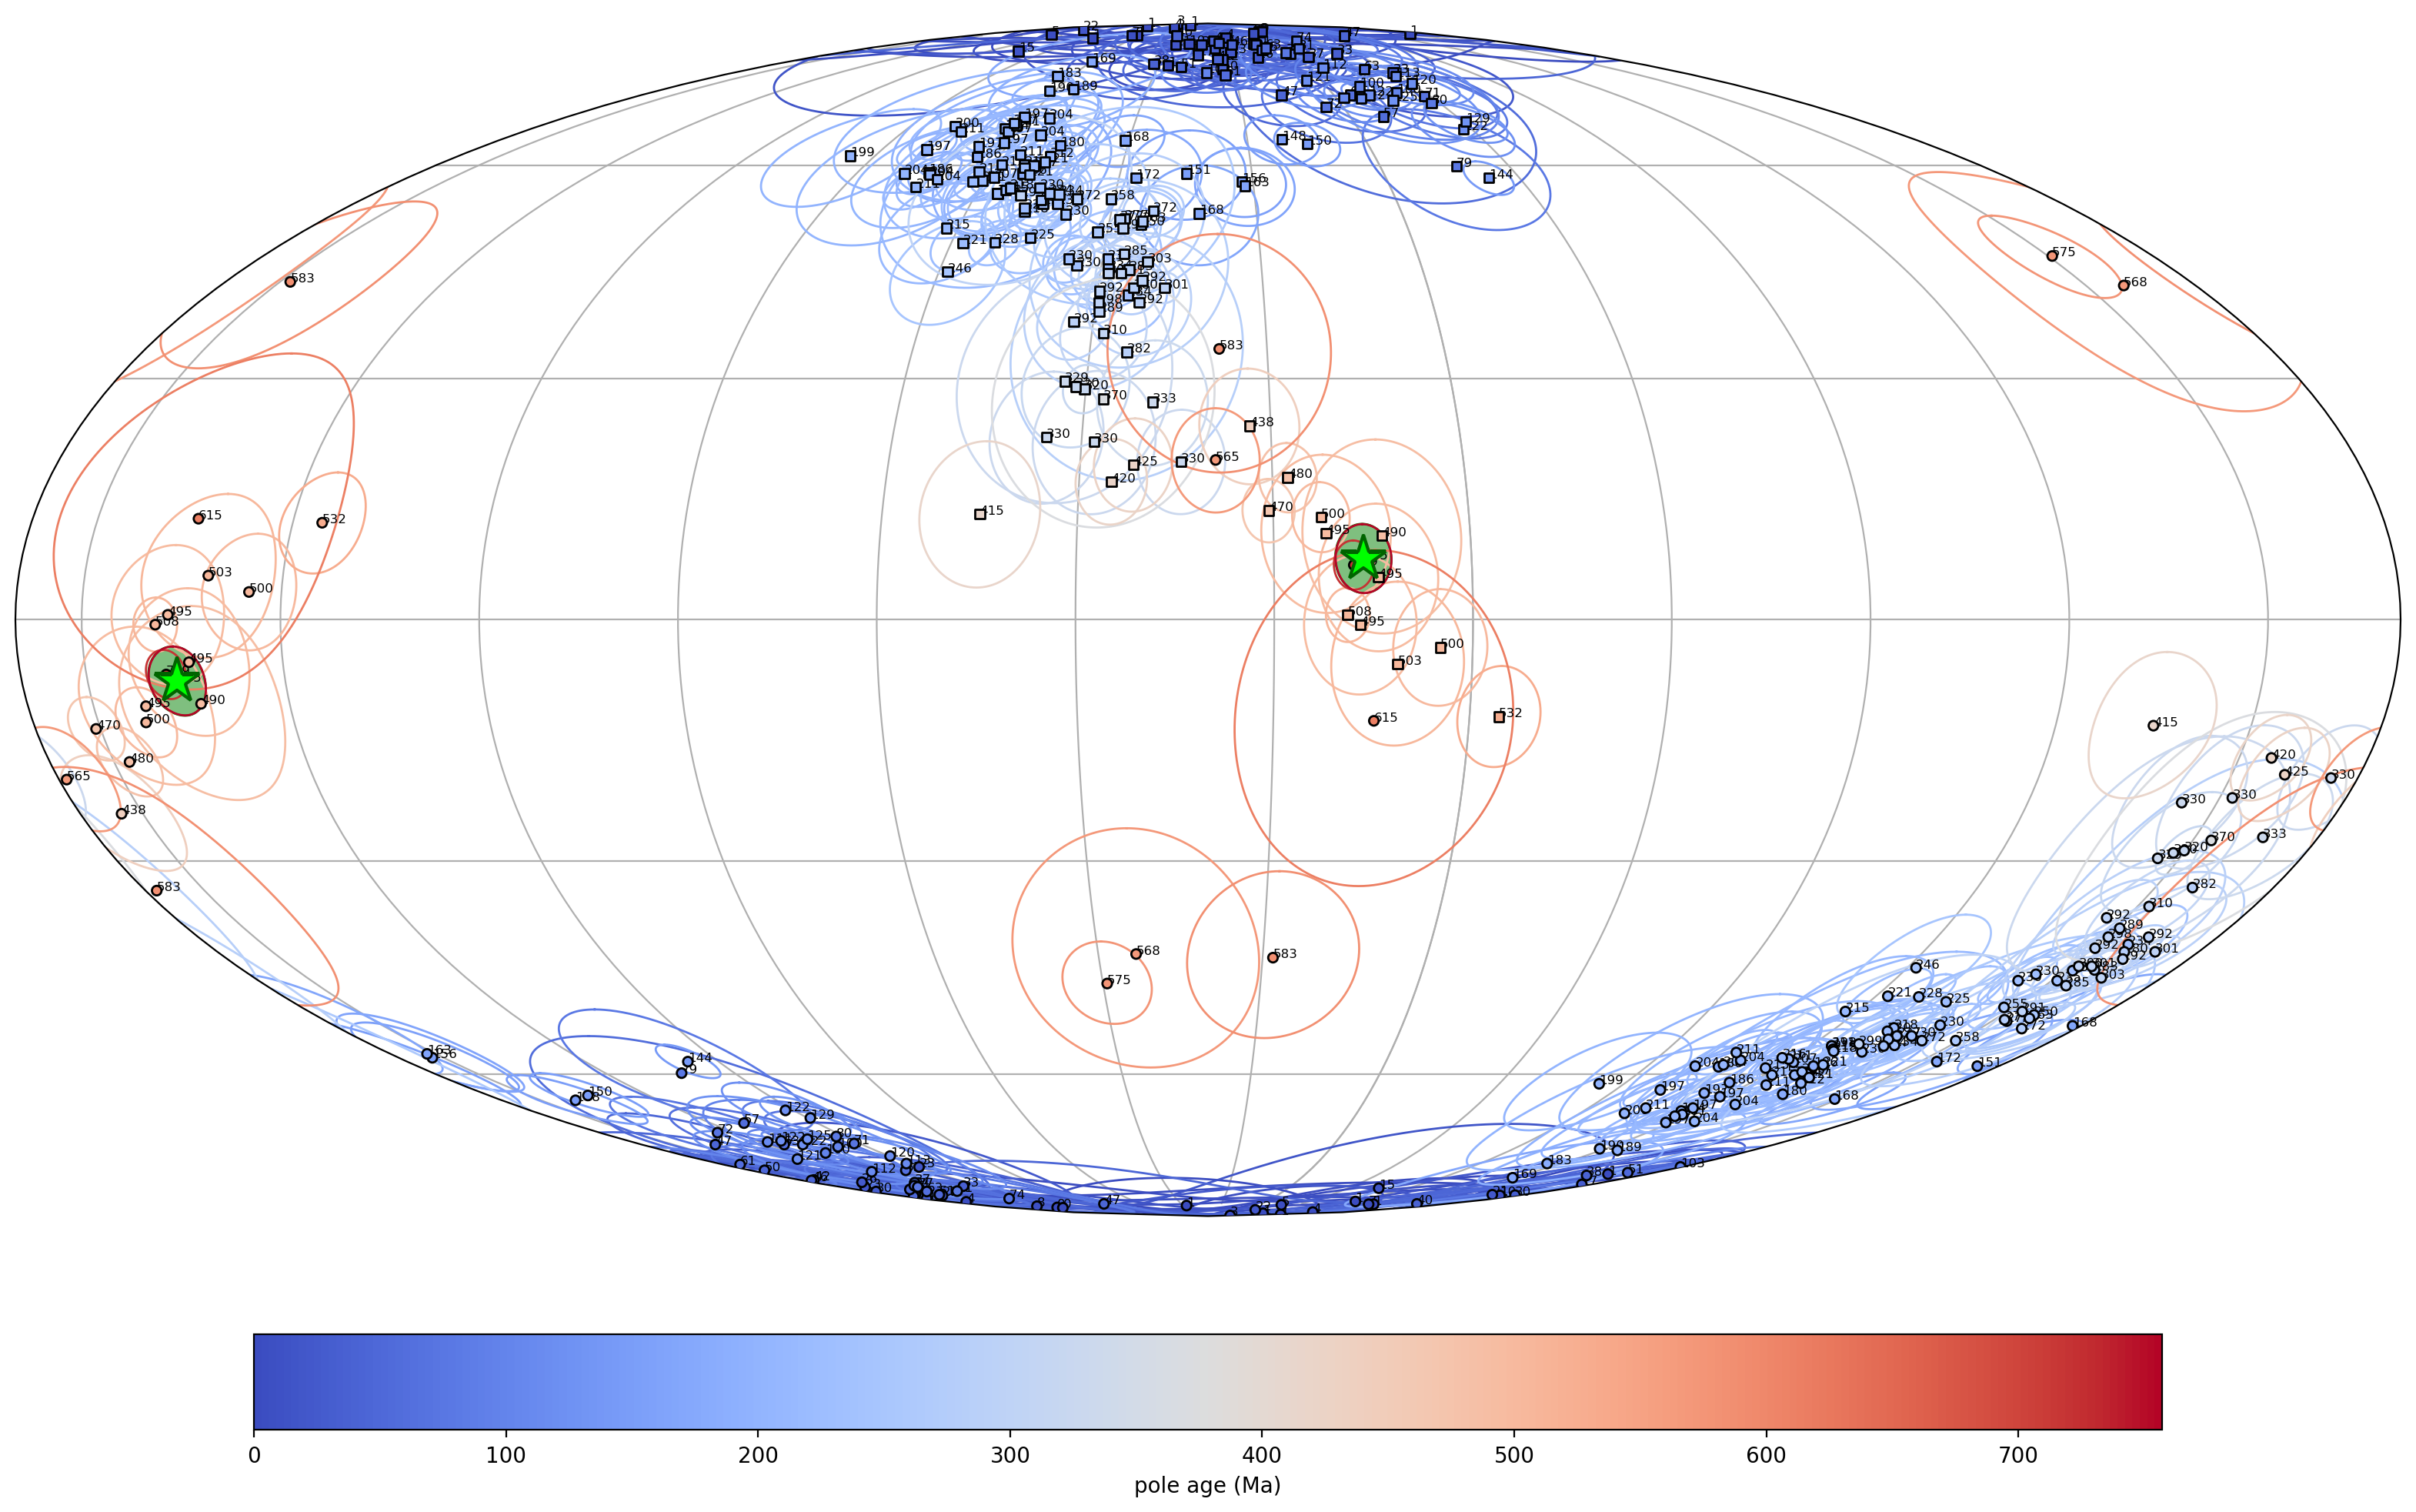

In [12]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
_ = pt.plot_pole_overlap('Chuar Group', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=chuar_pole['inc'], pole_plon=chuar_pole['dec'],
                     pole_A95=chuar_pole['alpha95'], pole_age=757)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | Member ages from the Dehler et al. (2023) U-Pb / Re-Os age model (Carbon Canyon 761.1 Ma; Carbon Butte-Awatubi 750.5 Ma) and Re-Os 751.0 ± 7.6 Ma on the Walcott Member (Rooney et al., 2017). |
| 2 | Techniques and statistical analysis | **1** | Thermal/AF demagnetization, PCA; N = 37 site/sample readings across three members, averaging paleosecular variation; A95 ≈ 4°. |
| 3 | Magnetic mineralogy characterized | **1** | Remanence carried by hematite, characterized by IRM/thermal experiments (Weil et al., 2004; Eyster et al., 2020). |
| 4 | Field tests constrain age of magnetization | **f** | Positive Tauxe & Watson (1994) fold test (66-109% unfolding; Eyster et al., 2020; Weil et al., 2004). |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous Grand Canyon Chuar basin; tilt-corrected. |
| 6 | Presence of reversals | **1** | Dual-polarity ChRM. The reversal test on the full combined set is confounded by inter-member APW; within the coeval Carbon Butte–Awatubi members it is positive (Watson V 7.4 < 7.6; MM1990 class C; Eyster et al., 2020). |
| 7 | No resemblance to younger poles | **0** | The pole lies within the mid-Neoproterozoic Laurentia cluster (e.g. the Uinta Mountain Group). |
| | Total | **6/7** | Grade A |

## Nordic workshop summary

The Chuar Group combined pole is a new pole spanning the Carbon Canyon, Carbon
Butte, and Awatubi members, computed as the equal-weight Fisher mean of 37
individual tilt-corrected site/sample VGPs, reproducing Eyster et al. (2020)
Table 1 (Carbon Butte–Awatubi N=23 + Carbon Canyon N=14). The 17 Eyster HT
readings are reconstructed from their Supplemental Table S2; the other 20 are Weil
et al. (2004) sites. The observed (uncorrected) pole is exported; Eyster et al.
(2020) derived E-I inclination-flattening factors of f = 0.9 (Carbon
Butte–Awatubi) and f = 0.5 (Carbon Canyon). Positive fold and reversal tests and
the ~757 Ma age give a Grade A pole. This combined pole sits at a lower
paleolatitude than the Kwagunt-only pole because it incorporates the older Carbon
Canyon member.

### Combined Chuar Group pole

| | This study (site VGPs) | Eyster et al. (2020) | Previous Nordic compilation |
|---|---|---|---|
| Component | HT (hematite), combined Carbon Canyon + Carbon Butte + Awatubi | Combined HT Carbon Butte–Awatubi | Component HT (Kwagunt Formation) |
| N (sites) | 37 | 23 | 23 |
| N (specimens) | 154 | — | 71 |
| Dec (°) | 272.7 | 98.2 | 98.2 |
| Inc (°) | 16.5 | −21.8 | −21.8 |
| k (direction) | 19.4 | 43.4 | 43.4 |
| α95 (direction, °) | 5.5 | 4.6 | 4.6 |
| Pole lat (°N) | 7.5 | 13.5 | 14.2 |
| Pole lon (°E) | 163.6 | 162.8 | 163.8 |
| A95 | 4.2 | 3.3 | 3.5 |
| pole (°) | — | — | — |
| dp / dm (°) | — / — | — / — | 3.5 / 3.5 |

This study additionally includes the older Carbon Canyon member (Eyster et al., 2020, Table 1: Carbon Canyon pole −2.1°N/163.7°E, A95 8.0°, N = 14), so its N and pole position differ from Eyster's Carbon Butte–Awatubi-only pole; averaging the ~10 Myr of apparent polar wander between the members shifts the combined pole to a lower paleolatitude (7.5°N vs 13.5°N). The Eyster et al. (2020) column is the Combined HT Carbon Butte–Awatubi pole of their Table 1 (p. 718; Pole 13.5/162.8, A95 3.3, N = 23; tilt-corrected direction 98.2/−21.8, k 43.4, α95 4.6). The previous Nordic-compilation "Kwagunt Formation" entry (RESULT# 9981; data/Laurentia_poles.csv) is that same Carbon Butte–Awatubi pole.


In [13]:
# combined ChRM mean direction at the study locality
_, chuar_dir = pt.compute_mean_direction(tc, unify_polarity=True)

chuar_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Chuar Group (combined)',
    sites=tc,
    dir_mean=chuar_dir,
    pole_mean=chuar_pole,
    study_lon=study_lon,
    study_lat=study_lat,
    lithology='sedimentary',
    component_comment='High-temperature characteristic remanent magnetization (hematite), dual polarity; combined Carbon Canyon + Carbon Butte + Awatubi members (37 readings); detrital sediments',
    tests='F+ (positive fold test, 66-109% unfolding) and R+ (positive reversal test within the coeval Carbon Butte-Awatubi members, Watson V 7.4<7.6, MM1990 class C; the full combined-set reversal test is confounded by inter-member APW) (Weil et al., 2004; Eyster et al., 2020)',
    gpmdb_number='',
    percent_reversed=50,
    demag_code=4,
    R1=1, R2=1, R3=1, R4='f', R5=1, R6=1, R7=0, Grade='A', Grade_E21='--',
    nominal_age=755, lomagage=748, himagage=761,
    REF_method='Member ages from the Dehler et al. (2023) U-Pb / Re-Os age model (Carbon Canyon 761.1 Ma; Carbon Butte-Awatubi 750.5 Ma); Re-Os 751.0 +/- 7.6 Ma on the Walcott Member (Rooney et al., 2017).',
    POLE_AUTHORS='Weil, A. B., Geissman, J. W., & Van der Voo, R.; Eyster, A., et al. (combined three-member pole)',
    YEAR=2020,
    JOURNAL='Precambrian Research; GSA Bulletin',
    VOLUME='129; 132',
    VPAGES='71-92; 710-738',
    TITLE='Paleomagnetism of the Neoproterozoic Chuar Group, Grand Canyon (Weil et al., 2004; Eyster et al., 2020)',
    COMMENT='New combined Chuar Group pole, Fisher mean of 37 individual tilt-corrected site VGPs: Carbon Butte-Awatubi (N=23) + Carbon Canyon (N=14). The 17 Eyster HT Carbon Butte-Awatubi readings are reconstructed from Supplemental Table S2 (GSA DR 2019239): linear shallow-HT fits with MAD<15 deg, one per sample (great-circle fits excluded as Eyster uses them only in locality means). This reproduces Eyster N=17 pole 12.5/161.6. Plus 6 Weil (2004) Carbon Butte + 14 Weil Carbon Canyon site VGPs.'
)
pt.save_nordic_summary(chuar_summary, '755_Chuar_Group')
chuar_summary

,Terrane,ROCKNAME,GPMDB RESULT#,MAGIC #,COMPONENT,TESTS,TILT,SLAT,SLONG,B,...,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment,Lithology
0,Laurentia,Chuar Group (combined),,,High-temperature characteristic remanent magne...,"F+ (positive fold test, 66-109% unfolding) and...",100,36.23,248.13,37,...,Member ages from the Dehler et al. (2023) U-Pb...,Chuar Group (combined),"Weil, A. B., Geissman, J. W., & Van der Voo, R...",2020,Precambrian Research; GSA Bulletin,129; 132,71-92; 710-738,Paleomagnetism of the Neoproterozoic Chuar Gro...,"New combined Chuar Group pole, Fisher mean of ...",Mudstone; Sandstone; Dolomite


## Inclination-shallowing-corrected pole

The pole above is reported as measured. Detrital remanence in sedimentary rocks
is shallowed during compaction, so its inclination — and the paleolatitude that
inclination implies — is a minimum. The combined pole rests on 37 site/sample virtual geomagnetic poles pooled from two studies — far fewer directions than an elongation/inclination (E/I) or SVEI determination of the flattening factor requires — so *f* cannot be recovered from these data.

Following Pierce et al. (2022), the flattening factor is instead resampled from
their compilation of measured *f* values (`ipmag.find_compilation_kent`). Each
resample unsquishes the mean direction implied by the pole at the sampling
locality, and the resulting distribution of mean poles is summarized as a Kent
(1982) distribution whose 95% confidence ellipse carries the flattening
uncertainty along with the uncertainty in the pole itself. This corrected pole
is exported to `data/nordic_summaries/kent/` and is the position plotted for
this unit in the compilation figures; the main compilation table keeps the
uncorrected pole.

Plon: 167.9  Plat: 10.6
Major axis lon: 265.4  Major axis lat: 35.0
Minor axis lon: 63.6  Minor axis lat: 52.9
Major axis angle of 95% ellipse (Zeta): 8.3
Minor axis angle of 95% ellipse (Eta): 4.2
Number of directions in mean (n): 7000


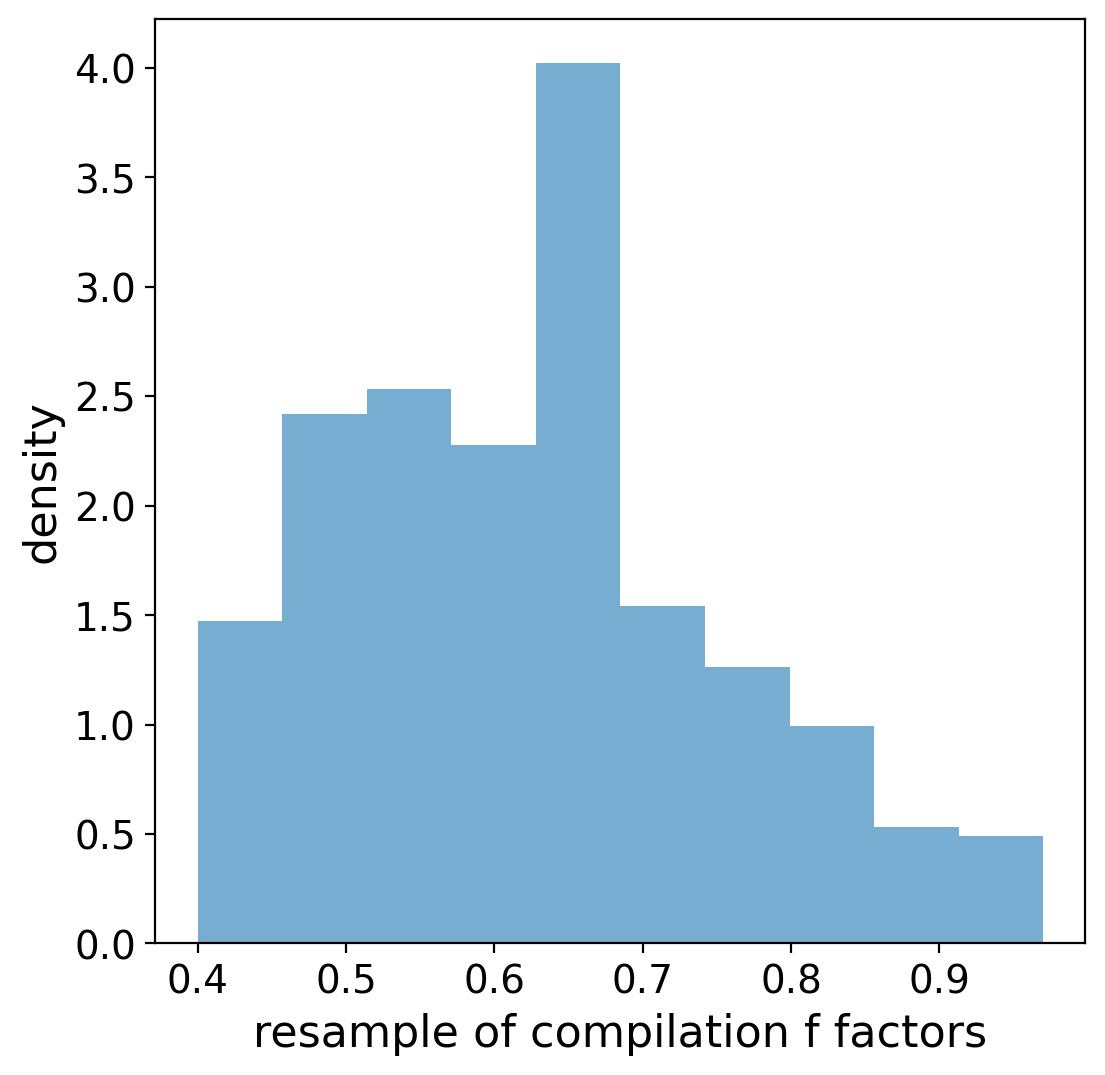

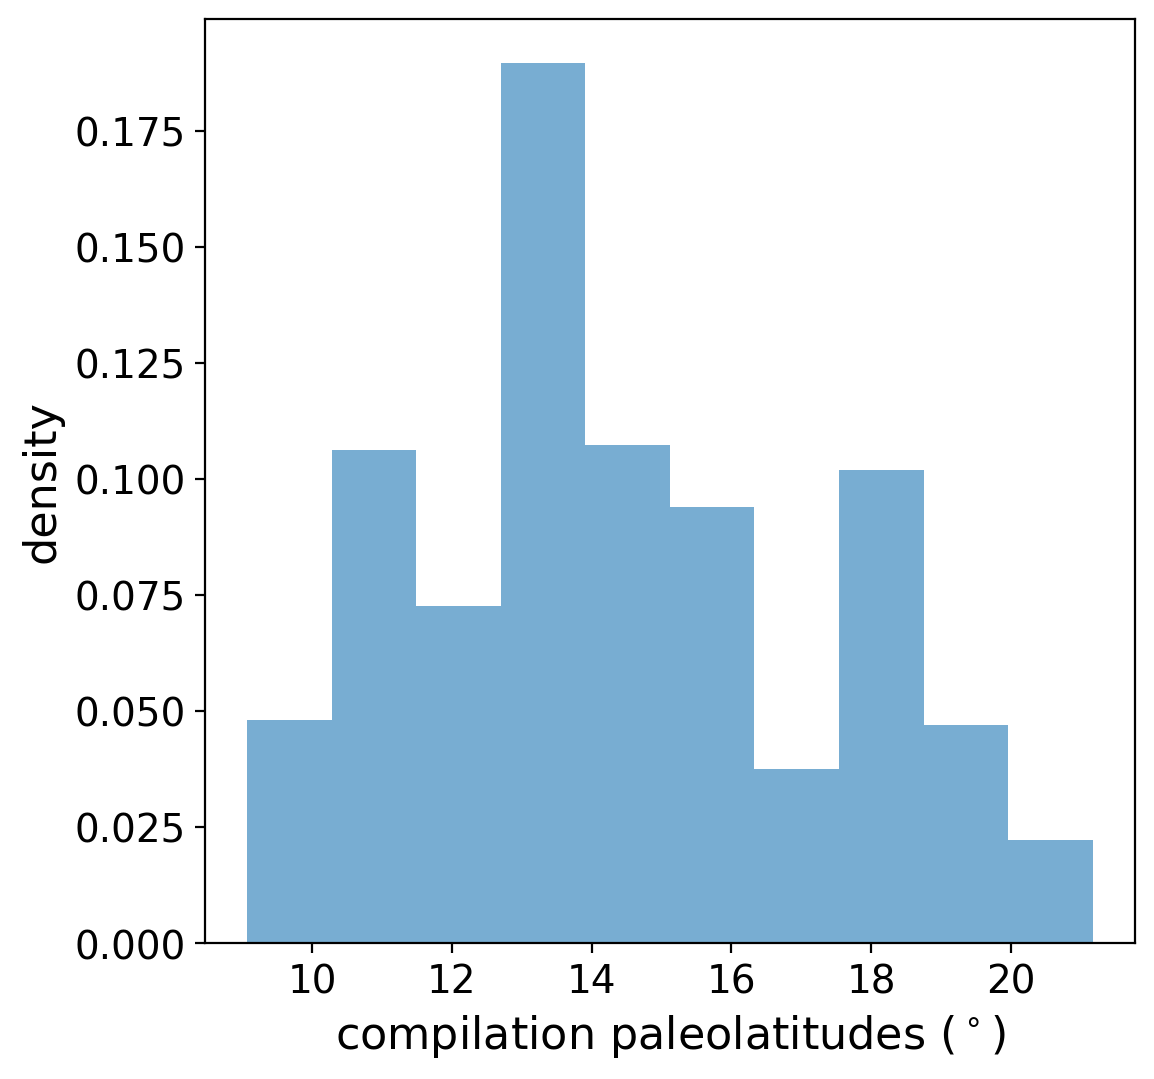

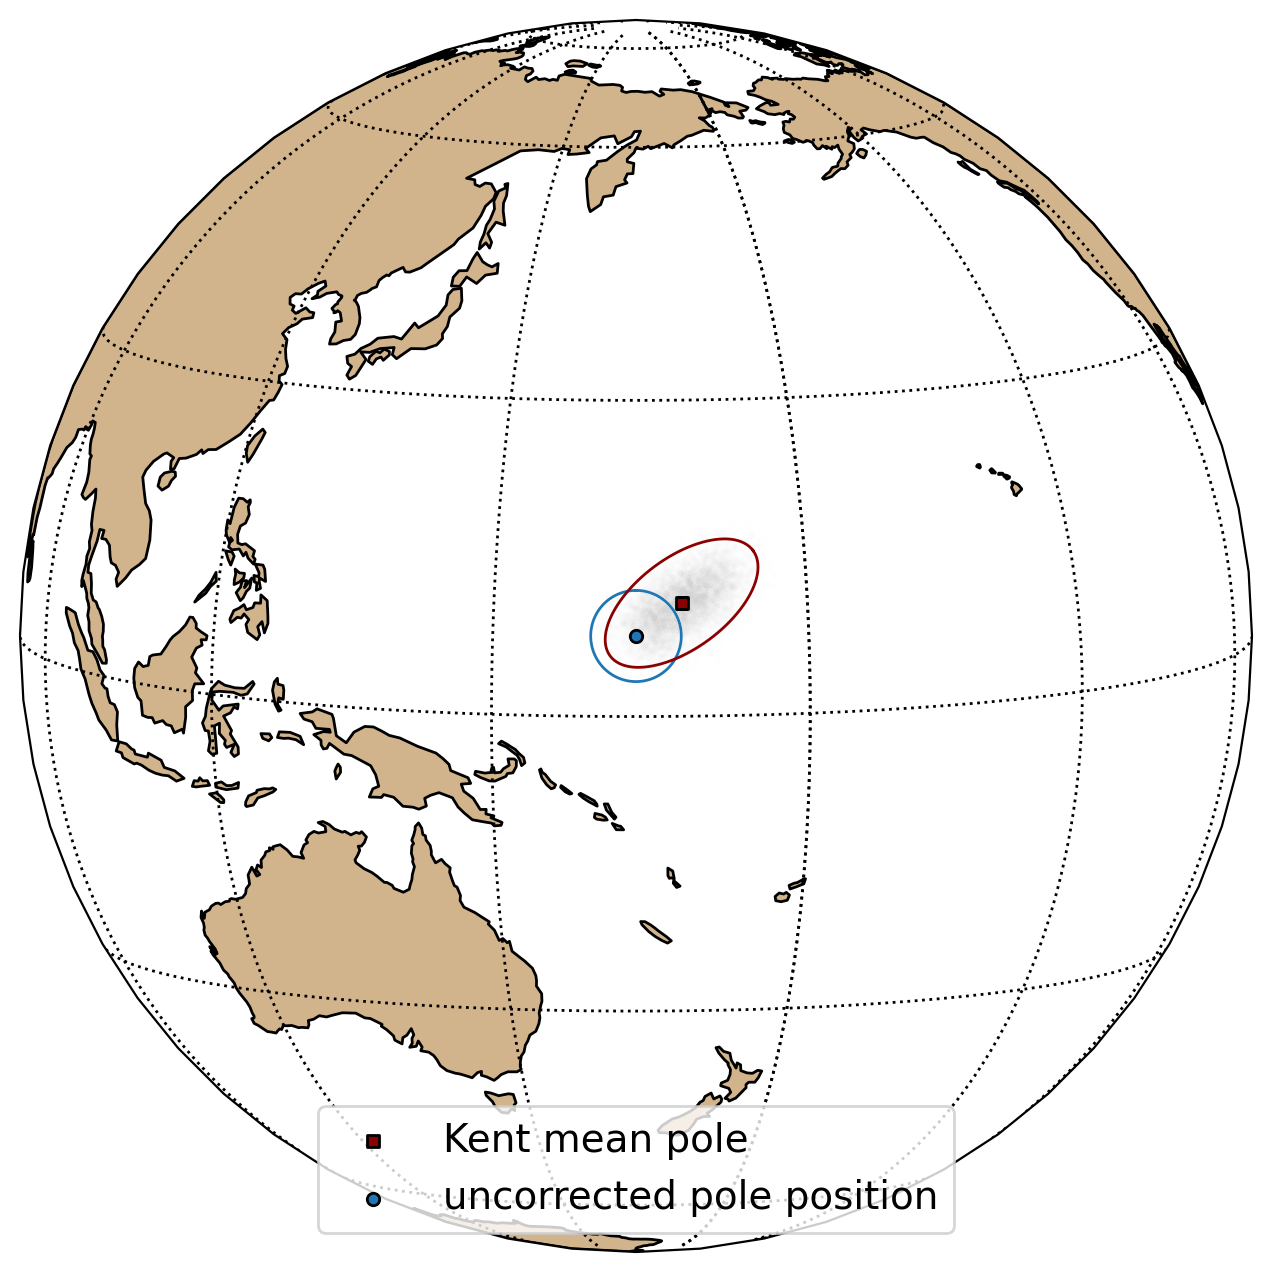

,Terrane,ROCKNAME,Lithology,SLAT,SLONG,nominal age,lomagage,himagage,Grade,f method,...,PLONG,Zdec,Zinc,Zeta,Edec,Einc,Eta,A95,n resampled,Comment
0,Laurentia,Chuar Group (combined),Mudstone; Sandstone; Dolomite,36.23,248.13,755,748,761,A,"compilation f (Pierce et al., 2022)",...,167.9,265.4,35.0,8.3,63.6,52.9,4.2,5.9,7000,37 pooled site/sample VGPs: too few directions...


In [14]:
# Inclination-shallowing-corrected Kent mean pole (Pierce et al., 2022). The
# random seed is fixed so the exported summary is reproducible.
kent = pt.compilation_kent_pole(chuar_pole, study_lon, study_lat, random_seed=1)
plt.show()

chuar_kent_summary = pt.make_kent_summary(
    chuar_summary, kent, 'compilation', 'this study',
    comment='37 pooled site/sample VGPs: too few directions for an E/I or SVEI determination of f')
pt.save_kent_summary(chuar_kent_summary, '755_Chuar_Group')
chuar_kent_summary